<a href="https://colab.research.google.com/github/rachakondasaivarshini/AIML-EXPS/blob/main/AIML_EXP_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Linear Regression on Boston Housing Dataset ---


/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:110: UserWarning: A network error occurred while downloading https://api.openml.org/api/v1/json/data/list/data_name/boston/limit/2/data_version/1. Retrying...
  warn(


Regression Coefficients:
 [-1.08011358e-01  4.64204584e-02  2.05586264e-02  2.68673382e+00
 -1.77666112e+01  3.80986521e+00  6.92224640e-04 -1.47556685e+00
  3.06049479e-01 -1.23345939e-02 -9.52747232e-01  9.31168327e-03
 -5.24758378e-01]
Intercept: 36.459488385089955

--- Logistic Regression on Iris Dataset ---
Model Coefficients:
 [[-2.66907706  1.81960448]
 [ 0.06060563 -1.36629458]
 [ 1.77099496 -0.10731709]]
Intercepts:
 [-1.78912983 -0.79448198 -0.86696201]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


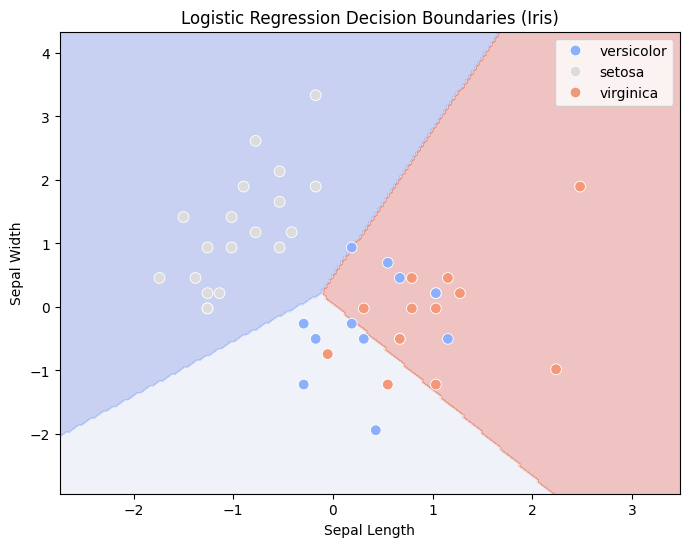

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml, load_iris
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ---------------- Linear Regression ----------------
print("\n--- Linear Regression on Boston Housing Dataset ---")

boston = fetch_openml(name='boston', version=1, as_frame=True)
X_boston = boston.data
y_boston = boston.target

lr = LinearRegression()
lr.fit(X_boston, y_boston)

print("Regression Coefficients:\n", lr.coef_)
print("Intercept:", lr.intercept_)

# ---------------- Logistic Regression ----------------
print("\n--- Logistic Regression on Iris Dataset ---")

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Use only first two features
X_iris_2d = X_iris[:, :2]

X_train, X_test, y_train, y_test = train_test_split(
    X_iris_2d, y_iris, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

logreg = LogisticRegression(
    C=1.0,
    penalty='l2',
    multi_class='ovr',
    solver='liblinear'
)

logreg.fit(X_train_std, y_train)

print("Model Coefficients:\n", logreg.coef_)
print("Intercepts:\n", logreg.intercept_)

# Decision Boundary Plot
def plot_decision_boundaries(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

    sns.scatterplot(
        x=X[:, 0],
        y=X[:, 1],
        hue=iris.target_names[y],
        palette='coolwarm',
        s=60
    )

    plt.xlabel('Sepal Length')
    plt.ylabel('Sepal Width')
    plt.title(title)
    plt.legend()
    plt.show()

plot_decision_boundaries(
    X_test_std,
    y_test,
    logreg,
    "Logistic Regression Decision Boundaries (Iris)"
)